# 01 - Multi-Dataset Exploration and Quality Audit

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"

GIT_COMMIT = None
if KAGGLE:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': 'db0fb5ec81c7227f183076cf7e8fa7b6d6ae21d6', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


In [2]:
from src.data import (
    load_config,
    load_fraud_dataframe,
    make_synthetic_baf_data,
    make_synthetic_fraud_data,
    prepare_dataset,
)

max_rows = 12000 if QUICK_RUN else None
output_dir = OUTPUT_BASE / "01_data_exploration"
output_dir.mkdir(parents=True, exist_ok=True)
dataset_summaries = []

## I. IEEE-CIS

In [3]:
config = load_config(PROJECT_ROOT / "configs/ieee_cis.yaml")
try:
    frame = load_fraud_dataframe(config, max_rows=max_rows)
    data_source = "real"
except FileNotFoundError:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    frame = make_synthetic_fraud_data(max_rows or 6000, seed=config["project"]["seed"])
    data_source = "synthetic"
print({"dataset": "IEEE-CIS", "data_source": data_source, "rows": len(frame), "columns": frame.shape[1]})
display(frame.head())

{'dataset': 'IEEE-CIS', 'data_source': 'real', 'rows': 590540, 'columns': 437}


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,...,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,transaction_hour,transaction_day,transaction_amount_log
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,4.241327
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,3.401197
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,4.094345
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,3.931826
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M,0,1,3.931826


In [4]:
target = config["dataset"]["target_column"]
time_column = config["dataset"]["time_column"]
summary = pd.DataFrame({
    "dataset": ["IEEE-CIS"],
    "rows": [len(frame)],
    "columns": [frame.shape[1]],
    "fraud_count": [int(frame[target].sum())],
    "fraud_rate": [float(frame[target].mean())],
    "duplicate_rows": [int(frame.duplicated().sum())],
    "data_source": [data_source],
})
missing = frame.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
prepared = prepare_dataset(frame, config)
split_summary = pd.DataFrame([
    {"split": "train", "rows": len(prepared.y_train), "fraud_rate": prepared.y_train.mean(),
     "time_min": prepared.train_frame[time_column].min(), "time_max": prepared.train_frame[time_column].max()},
    {"split": "validation", "rows": len(prepared.y_validation), "fraud_rate": prepared.y_validation.mean(),
     "time_min": prepared.validation_frame[time_column].min(), "time_max": prepared.validation_frame[time_column].max()},
    {"split": "test", "rows": len(prepared.y_test), "fraud_rate": prepared.y_test.mean(),
     "time_min": prepared.test_frame[time_column].min(), "time_max": prepared.test_frame[time_column].max()},
])
dataset_summaries.append(summary.copy())
display(summary, missing.head(20), split_summary)

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source
0,IEEE-CIS,590540,437,20663,0.03499,0,real


,missing_fraction
id_24,0.991962
id_25,0.991310
id_08,0.991271
id_07,0.991271
id_21,0.991264
id_26,0.991257
id_22,0.991247
id_27,0.991247
id_23,0.991247
dist2,0.936284


,split,rows,fraud_rate,time_min,time_max
0,train,413378,0.035169,86400,10437996
1,validation,88581,0.034341,10438003,13151840
2,test,88581,0.034804,13151880,15811131


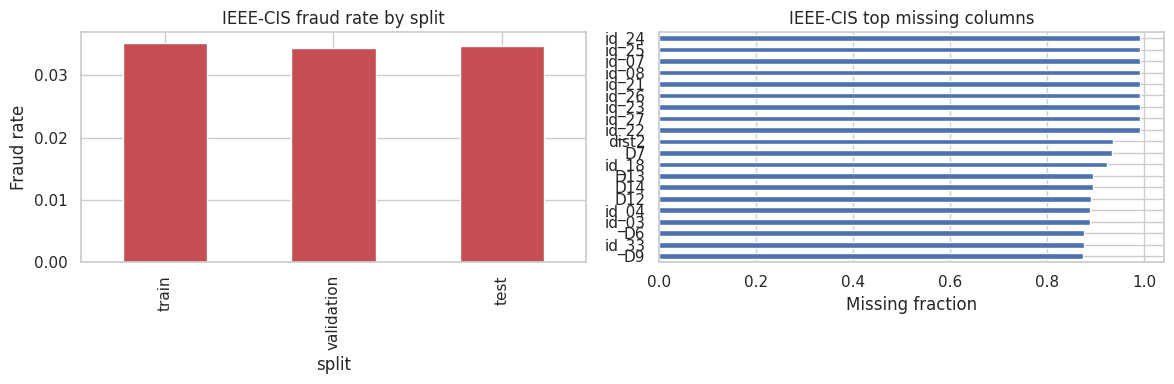

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
split_summary.plot.bar(x="split", y="fraud_rate", ax=axes[0], legend=False, color="#C44E52")
axes[0].set_title("IEEE-CIS fraud rate by split")
axes[0].set_ylabel("Fraud rate")
missing.head(20).sort_values("missing_fraction").plot.barh(ax=axes[1], legend=False, color="#4C72B0")
axes[1].set_title("IEEE-CIS top missing columns")
axes[1].set_xlabel("Missing fraction")
plt.tight_layout()
fig.savefig(output_dir / "ieee_cis_data_quality.png", dpi=160, bbox_inches="tight")
plt.show()

split_summary.to_csv(output_dir / "ieee_cis_split_summary.csv", index=False)
missing.to_csv(output_dir / "ieee_cis_missingness.csv")

## II. BAF

In [6]:
config = load_config(PROJECT_ROOT / "configs/baf.yaml")
try:
    frame = load_fraud_dataframe(config, max_rows=max_rows)
    data_source = "real"
except FileNotFoundError:
    if not ALLOW_SYNTHETIC_FALLBACK:
        raise
    frame = make_synthetic_baf_data(max_rows or 6000, seed=config["project"]["seed"])
    data_source = "synthetic"
print({"dataset": "BAF", "data_source": data_source, "rows": len(frame), "columns": frame.shape[1]})
display(frame.head())

{'dataset': 'BAF', 'data_source': 'real', 'rows': 1000000, 'columns': 32}


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


In [7]:
target = config["dataset"]["target_column"]
time_column = config["dataset"]["time_column"]
summary = pd.DataFrame({
    "dataset": ["BAF"],
    "rows": [len(frame)],
    "columns": [frame.shape[1]],
    "fraud_count": [int(frame[target].sum())],
    "fraud_rate": [float(frame[target].mean())],
    "duplicate_rows": [int(frame.duplicated().sum())],
    "data_source": [data_source],
})
missing = frame.isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
prepared = prepare_dataset(frame, config)
split_summary = pd.DataFrame([
    {"split": "train", "rows": len(prepared.y_train), "fraud_rate": prepared.y_train.mean(),
     "time_min": prepared.train_frame[time_column].min(), "time_max": prepared.train_frame[time_column].max()},
    {"split": "validation", "rows": len(prepared.y_validation), "fraud_rate": prepared.y_validation.mean(),
     "time_min": prepared.validation_frame[time_column].min(), "time_max": prepared.validation_frame[time_column].max()},
    {"split": "test", "rows": len(prepared.y_test), "fraud_rate": prepared.y_test.mean(),
     "time_min": prepared.test_frame[time_column].min(), "time_max": prepared.test_frame[time_column].max()},
])
dataset_summaries.append(summary.copy())
display(summary, missing.head(20), split_summary)

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source
0,BAF,1000000,32,11029,0.011029,0,real


,missing_fraction
fraud_bool,0.0
income,0.0
name_email_similarity,0.0
prev_address_months_count,0.0
current_address_months_count,0.0
customer_age,0.0
days_since_request,0.0
intended_balcon_amount,0.0
payment_type,0.0
zip_count_4w,0.0


,split,rows,fraud_rate,time_min,time_max
0,train,700000,0.010063,0,5
1,validation,150000,0.012333,5,6
2,test,150000,0.014233,6,7


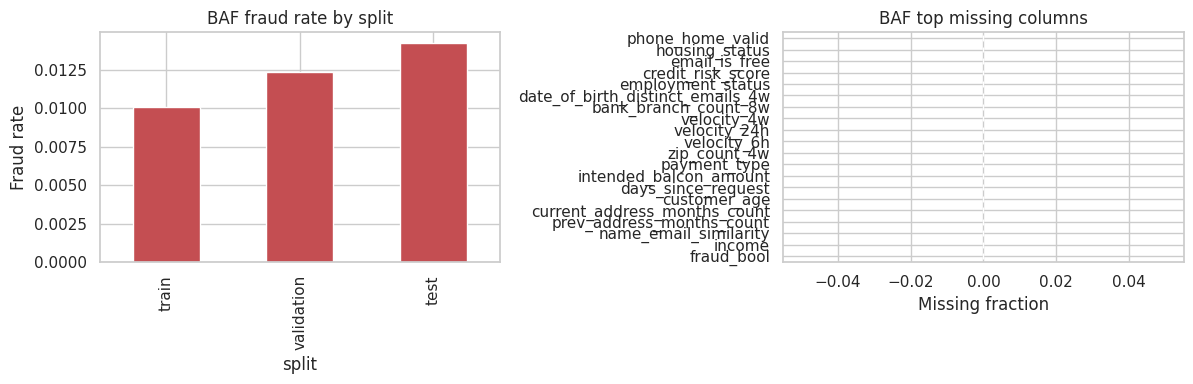

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
split_summary.plot.bar(x="split", y="fraud_rate", ax=axes[0], legend=False, color="#C44E52")
axes[0].set_title("BAF fraud rate by split")
axes[0].set_ylabel("Fraud rate")
missing.head(20).sort_values("missing_fraction").plot.barh(ax=axes[1], legend=False, color="#4C72B0")
axes[1].set_title("BAF top missing columns")
axes[1].set_xlabel("Missing fraction")
plt.tight_layout()
fig.savefig(output_dir / "baf_data_quality.png", dpi=160, bbox_inches="tight")
plt.show()

split_summary.to_csv(output_dir / "baf_split_summary.csv", index=False)
missing.to_csv(output_dir / "baf_missingness.csv")

## III. So sánh tổng quan

,dataset,rows,columns,fraud_count,fraud_rate,duplicate_rows,data_source
0,IEEE-CIS,590540,437,20663,0.034990,0,real
1,BAF,1000000,32,11029,0.011029,0,real


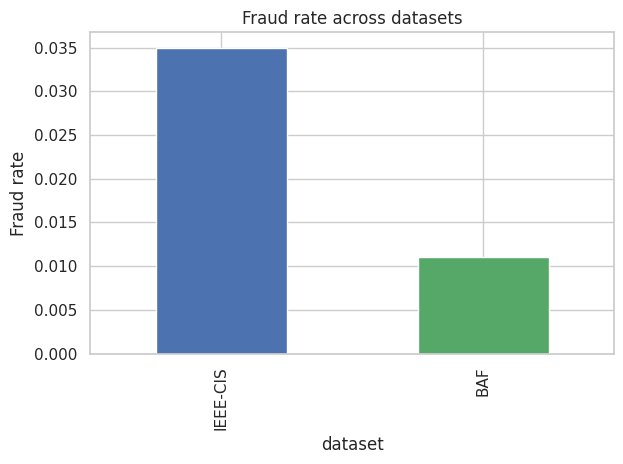

In [9]:
combined_summary = pd.concat(dataset_summaries, ignore_index=True)
display(combined_summary)
ax = combined_summary.plot.bar(x="dataset", y="fraud_rate", legend=False, color=["#4C72B0", "#55A868"])
ax.set_title("Fraud rate across datasets")
ax.set_ylabel("Fraud rate")
plt.tight_layout()
plt.savefig(output_dir / "dataset_fraud_rate_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
combined_summary.to_csv(output_dir / "dataset_summary.csv", index=False)